# 미니프로젝트: 결측치·이상치·클래스 불균형 처리 (Vibe Coding)

#### <목표>
오늘 배운 **결측치/이상치 처리, Under/Oversampling, SVDD**를 **통신사 고객 이탈(Customer Churn) 데이터셋**에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>
- Telco Customer Churn (통신사 고객 이탈 데이터)
- 고객의 인적사항, 가입 서비스, 요금·계약 정보와 이탈(Churn) 여부를 담은 데이터

| 변수명 | 설명 |
|:---:|:---|
| gender, SeniorCitizen, Partner, Dependents | 고객 인적사항 |
| tenure | 가입 개월 수 |
| PhoneService, MultipleLines, InternetService 등 | 가입 서비스 종류 |
| Contract, PaperlessBilling, PaymentMethod | 계약/결제 정보 |
| MonthlyCharges, TotalCharges | 월/누적 요금 |
| Churn | 이탈 여부 (Yes: 이탈, No: 유지) |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 분류 | `Churn` | 고객 정보로 이탈 여부 예측 |

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day4_miniproject.csv` 파일을 사용하기
- 타겟 변수: `Churn` (No: 유지, Yes: 이탈)

**[과제]** 써니는 통신사 고객 이탈 데이터를 분석하게 되었습니다. 분석에 필요한 라이브러리를 호출하고 데이터를 불러와 구조를 확인하는 코드를 AI와 상의해서 작성하세요.

In [4]:
# [Section 0] 분석 준비 — 라이브러리 호출 + 데이터 로드 + 구조 확인

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.manifold import TSNE
from sklearn.svm import OneClassSVM
from sklearn.impute import SimpleImputer, KNNImputer

from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

# 데이터 로드
df = pd.read_csv(os.path.join("dataset", "day4_miniproject.csv"))

# 구조 확인
print("=== 데이터 크기 ===")
print(f"행: {df.shape[0]:,}  |  열: {df.shape[1]}")

print("\n=== 컬럼 정보 (.info) ===")
df.info()

print("\n=== 타겟(Churn) 분포 ===")
print(df["Churn"].value_counts())

print("\n=== 상위 5행 ===")
df.head()


=== 데이터 크기 ===
행: 7,043  |  열: 20

=== 컬럼 정보 (.info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            6832 non-null   float64
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   6903 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null 

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1) 데이터 탐색 (EDA)

### 1-1) 기본 EDA 진행

**[과제]** 써니는 데이터 분석 전, 데이터의 구조적 및 통계적 정보가 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

In [5]:
# [Section 1-1] 기본 EDA — 구조적·통계적 정보 확인

# 수치형 / 범주형 변수 구분
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("=== 변수 유형 ===")
print(f"수치형 ({len(num_cols)}): {num_cols}")
print(f"범주형 ({len(cat_cols)}): {cat_cols}")

# 수치형 통계 요약
print("\n=== 수치형 describe() ===")
display(df[num_cols].describe().T)

# 범주형 통계 요약 (고유값 수, 최빈값 등)
print("\n=== 범주형 describe(include='all') ===")
display(df[cat_cols].describe(include="all").T)

# 범주형 변수별 고유값 개수
print("\n=== 범주형 변수별 nunique ===")
print(df[cat_cols].nunique().sort_values(ascending=False))


=== 변수 유형 ===
수치형 (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
범주형 (16): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

=== 수치형 describe() ===


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0000,0.000,0.0000,1.00
tenure,6832.0,32.376903,24.570605,0.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,6832.0,64.758255,30.077758,18.25,35.5875,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80



=== 범주형 describe(include='all') ===


,count,unique,top,freq
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,6903,3,Fiber optic,3033
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095
TechSupport,7043,3,No,3473



=== 범주형 변수별 nunique ===
PaymentMethod       4
OnlineBackup        3
InternetService     3
OnlineSecurity      3
TechSupport         3
StreamingTV         3
DeviceProtection    3
MultipleLines       3
StreamingMovies     3
Contract            3
Dependents          2
PhoneService        2
gender              2
Partner             2
PaperlessBilling    2
Churn               2
dtype: int64


**[과제]** 써니는 EDA를 통해 전처리가 필요한 부분을 발견했습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

> Tip: 'Churn' 변수의 타입이나 값 표기 방식

In [6]:
# [Section 1-1] EDA — 전처리가 필요한 부분 발견 및 1차 정리

df_clean = df.copy()

# --- 1) Churn: Yes/No 문자열 → 1/0 (이탈=1, 이벤트 관점) ---
print("=== [1] Churn 인코딩 ===")
print("변환 전:", df_clean["Churn"].value_counts().to_dict())
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})
print("변환 후:", df_clean["Churn"].value_counts().to_dict())

# --- 2) 결측치 현황 (여러 변수에 동시 존재) ---
print("\n=== [2] 결측치가 있는 변수 ===")
missing_cols = df_clean.isna().sum()
missing_cols = missing_cols[missing_cols > 0].sort_values(ascending=False)
print(missing_cols)
print("\n→ tenure / MonthlyCharges / PaymentMethod 등 211개는 같은 행에서 동시 결측인 경우가 많음")

# --- 3) TotalCharges: 결측 + tenure·MonthlyCharges와 강한 관련 ---
print("\n=== [3] TotalCharges 특이사항 ===")
print("dtype:", df_clean["TotalCharges"].dtype)
print("결측:", df_clean["TotalCharges"].isna().sum(), "개")
print("tenure×MonthlyCharges와 상관 높음 → 누적 요금 성격 (다중공선성 주의)")

# --- 4) tenure 결측: 대치가 유리 ---
print("\n=== [4] tenure 결측 처리 방향 ===")
print(f"tenure 결측: {df_clean['tenure'].isna().sum()}개 / {len(df_clean)}개")
print("→ 비율 약 3%로 낮음 → Section 2에서 중앙값 등 대치 (행 삭제보다 유리)")

# --- 전처리 요약표 ---
print("\n=== 전처리 요약 ===")
issues = pd.DataFrame({
    "항목": ["Churn", "tenure 등", "TotalCharges", "범주형 변수"],
    "문제": ["Yes/No 문자열", "결측 211개(동시 발생)", "결측 11개 + 누적요금 특성", "object 타입 → 인코딩 필요"],
    "조치": ["Yes=1, No=0", "대치(중앙값/최빈값)", "대치 또는 tenure×요금 활용", "Label/One-Hot 인코딩"],
})
display(issues)

df_clean.head()


=== [1] Churn 인코딩 ===
변환 전: {'No': 5174, 'Yes': 1869}
변환 후: {0: 5174, 1: 1869}

=== [2] 결측치가 있는 변수 ===
tenure             211
PaymentMethod      211
MonthlyCharges     211
InternetService    140
TotalCharges        11
dtype: int64

→ tenure / MonthlyCharges / PaymentMethod 등 211개는 같은 행에서 동시 결측인 경우가 많음

=== [3] TotalCharges 특이사항 ===
dtype: float64
결측: 11 개
tenure×MonthlyCharges와 상관 높음 → 누적 요금 성격 (다중공선성 주의)

=== [4] tenure 결측 처리 방향 ===
tenure 결측: 211개 / 7043개
→ 비율 약 3%로 낮음 → Section 2에서 중앙값 등 대치 (행 삭제보다 유리)

=== 전처리 요약 ===


,항목,문제,조치
0,Churn,Yes/No 문자열,"Yes=1, No=0"
1,tenure 등,결측 211개(동시 발생),대치(중앙값/최빈값)
2,TotalCharges,결측 11개 + 누적요금 특성,대치 또는 tenure×요금 활용
3,범주형 변수,object 타입 → 인코딩 필요,Label/One-Hot 인코딩


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


### 1-2) 결측치 현황 파악

**[과제]** 써니는 데이터에 결측치가 존재하는지, 존재한다면 어떤 형태로 얼마나 있는지 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

=== 컬럼별 결측치 개수 ===
tenure             211
PaymentMethod      211
MonthlyCharges     211
InternetService    140
TotalCharges        11
dtype: int64

전체 결측 셀 수: 784


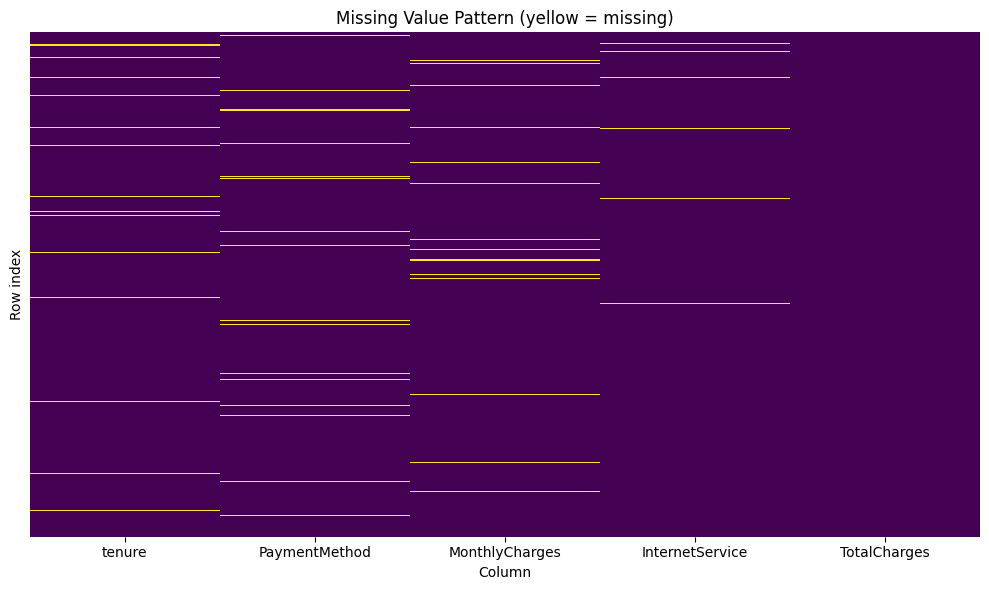


=== 동시 결측 패턴 ===
tenure·MonthlyCharges 동시 결측: 3개
5개 변수 중 하나라도 결측인 행: 763개
→ 컬럼별 결측 '개수'가 같아도(211) 반드시 같은 행은 아님
→ 행 삭제 시 최대 763 행 손실 가능 → 대치가 더 안전


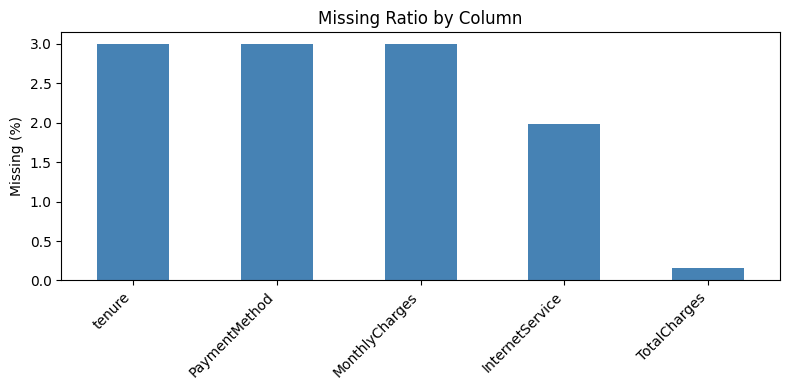

In [7]:
# [Section 1-2] 결측치 현황 파악
# (plot title/label: English to avoid Korean font issues)

# --- 1) 컬럼별 결측치 개수 ---
missing_cnt = df_clean.isna().sum()
missing_cnt = missing_cnt[missing_cnt > 0].sort_values(ascending=False)
print("=== 컬럼별 결측치 개수 ===")
print(missing_cnt)
print(f"\n전체 결측 셀 수: {df_clean.isna().sum().sum()}")

# --- 2) 결측 패턴 heatmap (행×열 중 어디가 비었는지) ---
cols_with_na = missing_cnt.index.tolist()
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean[cols_with_na].isna(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Value Pattern (yellow = missing)")
plt.xlabel("Column")
plt.ylabel("Row index")
plt.tight_layout()
plt.show()

# --- 3) 동시 결측 패턴 분석 ---
overlap_tm = (df_clean["tenure"].isna() & df_clean["MonthlyCharges"].isna()).sum()
any_missing = df_clean[cols_with_na].isna().any(axis=1).sum()
print("\n=== 동시 결측 패턴 ===")
print(f"tenure·MonthlyCharges 동시 결측: {overlap_tm}개")
print(f"5개 변수 중 하나라도 결측인 행: {any_missing}개")
print("→ 컬럼별 결측 '개수'가 같아도(211) 반드시 같은 행은 아님")
print("→ 행 삭제 시 최대", any_missing, "행 손실 가능 → 대치가 더 안전")

# 결측 비율 막대그래프
plt.figure(figsize=(8, 4))
(missing_cnt / len(df_clean) * 100).plot(kind="bar", color="steelblue")
plt.ylabel("Missing (%)")
plt.title("Missing Ratio by Column")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 1-3) 클래스 불균형 확인

**[과제]** 써니는 Churn 비율이 얼마나 불균형한지 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

=== Churn 클래스 분포 ===
               count  ratio(%)
Churn                         
0 (No/retain)   5174     73.46
1 (Yes/churn)   1869     26.54

소수 클래스(Churn=1): 26.5%
→ 다수 클래스(No=0)가 약 73%, 불균형 존재 → F1 기준 평가·Resampling 고려


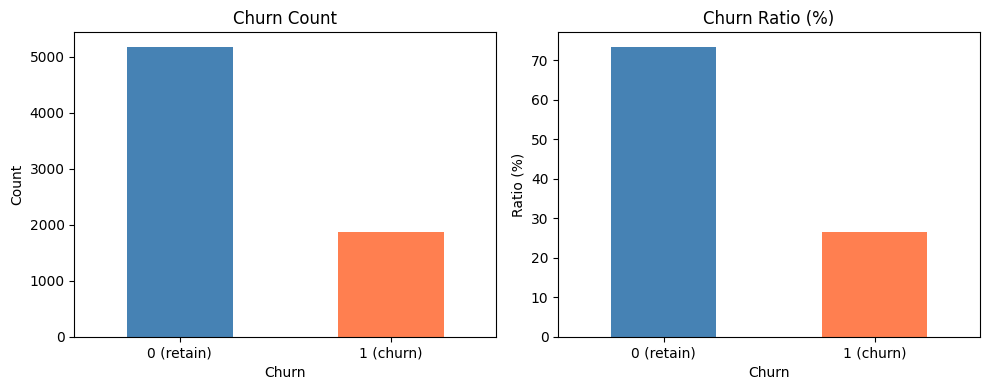

In [8]:
# [Section 1-3] 클래스 불균형 확인
# (plot title/label: English)

churn_cnt = df_clean["Churn"].value_counts().sort_index()
churn_ratio = df_clean["Churn"].value_counts(normalize=True).sort_index() * 100

print("=== Churn 클래스 분포 ===")
summary = pd.DataFrame({
    "count": churn_cnt,
    "ratio(%)": churn_ratio.round(2),
})
summary.index = summary.index.map({0: "0 (No/retain)", 1: "1 (Yes/churn)"})
print(summary)

minority_ratio = churn_ratio[1]
print(f"\n소수 클래스(Churn=1): {minority_ratio:.1f}%")
print("→ 다수 클래스(No=0)가 약 73%, 불균형 존재 → F1 기준 평가·Resampling 고려")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

churn_cnt.plot(kind="bar", ax=axes[0], color=["steelblue", "coral"])
axes[0].set_title("Churn Count")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["0 (retain)", "1 (churn)"], rotation=0)

churn_ratio.plot(kind="bar", ax=axes[1], color=["steelblue", "coral"])
axes[1].set_title("Churn Ratio (%)")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Ratio (%)")
axes[1].set_xticklabels(["0 (retain)", "1 (churn)"], rotation=0)

plt.tight_layout()
plt.show()


**[과제]** 써니는 수치형 변수에 이상치가 있는지 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

=== IQR 이상치 요약 (Churn 제외) ===
      variable  outlier_count  outlier_ratio(%)
 SeniorCitizen           1142             16.21
        tenure              0              0.00
MonthlyCharges              0              0.00
  TotalCharges              0              0.00


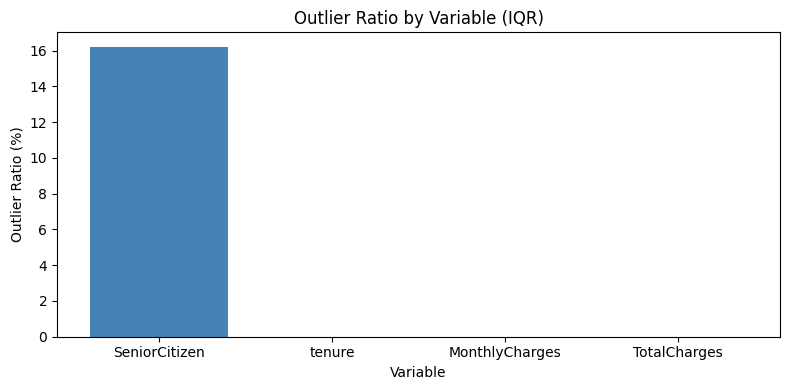

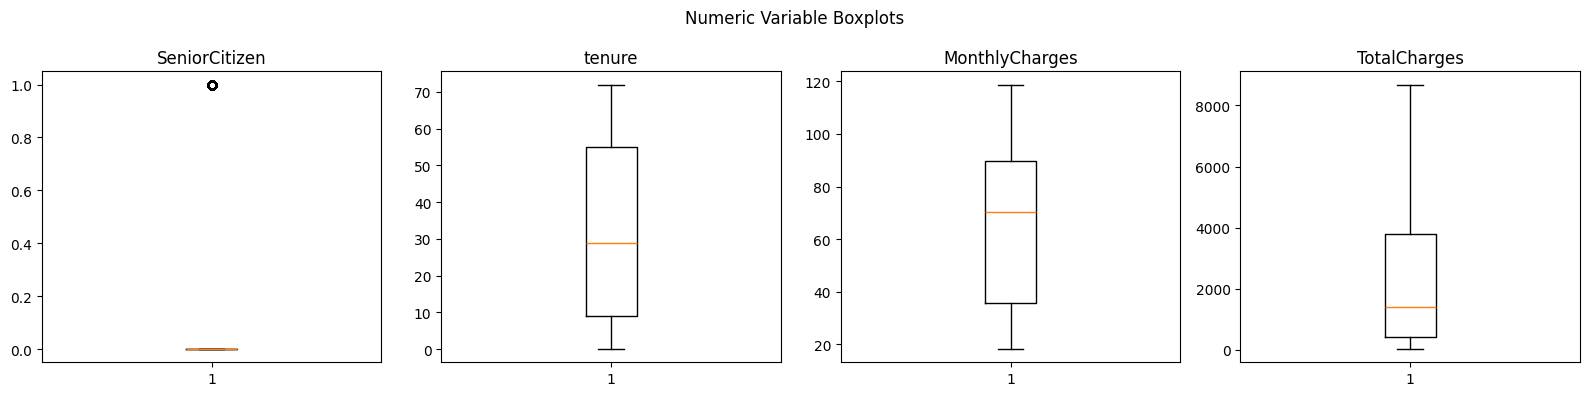

In [9]:
# [Section 1-4] 이상치 후보 탐색 (IQR)
# (plot title/label: English)

num_cols_eda = [c for c in df_clean.select_dtypes(include=["int64", "float64"]).columns if c != "Churn"]

def count_outliers_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

outlier_summary = []
for col in num_cols_eda:
    valid = df_clean[col].dropna()
    n_out = count_outliers_iqr(valid)
    outlier_summary.append({
        "variable": col,
        "outlier_count": n_out,
        "outlier_ratio(%)": round(n_out / len(valid) * 100, 2),
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("outlier_ratio(%)", ascending=False)
print("=== IQR 이상치 요약 (Churn 제외) ===")
print(outlier_df.to_string(index=False))

# 변수별 이상치 비율 막대그래프
plt.figure(figsize=(8, 4))
plt.bar(outlier_df["variable"], outlier_df["outlier_ratio(%)"], color="steelblue")
plt.title("Outlier Ratio by Variable (IQR)")
plt.xlabel("Variable")
plt.ylabel("Outlier Ratio (%)")
plt.tight_layout()
plt.show()

# boxplot으로 분포 확인
fig, axes = plt.subplots(1, len(num_cols_eda), figsize=(4 * len(num_cols_eda), 4))
if len(num_cols_eda) == 1:
    axes = [axes]
for ax, col in zip(axes, num_cols_eda):
    ax.boxplot(df_clean[col].dropna())
    ax.set_title(col)
plt.suptitle("Numeric Variable Boxplots")
plt.tight_layout()
plt.show()


## 2) 결측치 처리

**[과제]** 써니는 데이터셋에 존재하는 결측치를 제거하거나 대치하려 합니다.

이때 변수마다 분포나 특성이 다르면 적합한 대치법도 달라질 수 있다고 생각합니다.

AI와 상의하여 변수별로 제거와 대치 중 어떤 방법이 적합한지 결정하고, 대치를 선택했다면 값 기반, 통계 기반(평균/중앙값/최빈값), 머신러닝 기반(KNN Imputer) 중 어떤 방식이 적합한지 정하여 적용해보세요.

In [10]:
# [Section 2] 결측치 처리
# 전략: 범주형 → 최빈값(mode) / 수치형 → KNN Imputer (스케일 후)

df_imputed = df_clean.copy()

cat_cols_miss = ["InternetService", "PaymentMethod"]
num_cols_all = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

print("=== 처리 전 결측치 ===")
print(df_imputed.isna().sum()[df_imputed.isna().sum() > 0])

# 1) 범주형: 최빈값 대치
cat_imputer = SimpleImputer(strategy="most_frequent")
df_imputed[cat_cols_miss] = cat_imputer.fit_transform(df_imputed[cat_cols_miss])

# 2) 수치형: KNN Imputer (거리 기반이므로 StandardScaler 후 적용)
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(df_imputed[num_cols_all])

knn_imputer = KNNImputer(n_neighbors=5)
X_num_imputed = knn_imputer.fit_transform(X_num_scaled)
df_imputed[num_cols_all] = scaler.inverse_transform(X_num_imputed)

print("\n=== 처리 후 결측치 ===")
print("남은 결측:", df_imputed.isna().sum().sum())

# 변수별 처리 요약
summary_imp = pd.DataFrame({
    "variable": cat_cols_miss + num_cols_all,
    "type": ["categorical"] * len(cat_cols_miss) + ["numeric"] * len(num_cols_all),
    "method": ["mode (most_frequent)"] * len(cat_cols_miss) + ["KNN (k=5, after scaling)"] * len(num_cols_all),
})
print("\n=== 변수별 대치 방법 ===")
print(summary_imp.to_string(index=False))


=== 처리 전 결측치 ===
tenure             211
InternetService    140
PaymentMethod      211
MonthlyCharges     211
TotalCharges        11
dtype: int64

=== 처리 후 결측치 ===
남은 결측: 0

=== 변수별 대치 방법 ===
       variable        type                   method
InternetService categorical     mode (most_frequent)
  PaymentMethod categorical     mode (most_frequent)
  SeniorCitizen     numeric KNN (k=5, after scaling)
         tenure     numeric KNN (k=5, after scaling)
 MonthlyCharges     numeric KNN (k=5, after scaling)
   TotalCharges     numeric KNN (k=5, after scaling)


## 3) 이상치 처리

**[과제]** 써니는 데이터셋에 존재하는 이상치를 제거하고자 합니다.

다만 이탈(Churn) 고객이 실제로는 "정상 범위를 벗어난" 요금 및 이용 패턴을 가진 고객일 수 있다는 점이 마음에 걸립니다. 이상치 제거가 소수 클래스(Churn)를 함께 지워버릴 위험은 없는지 AI와 상의하여 검토하고 안전한 처리 기준을 정해 적용해 보세요.

In [12]:
# [Section 3] 이상치 처리 — 윈저화(clip) 적용
# 선택 이유: 행 삭제 시 Churn(소수 클래스) 손실 위험 → 값만 조정, 행 유지

num_feat = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

def winsorize_iqr(df_in, cols):
    df_out = df_in.copy()
    clipped_total = 0
    for col in cols:
        q1, q3 = df_out[col].quantile(0.25), df_out[col].quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        before = df_out[col].copy()
        df_out[col] = df_out[col].clip(lo, hi)
        clipped_total += (before != df_out[col]).sum()
    return df_out, clipped_total

# 비교: 순차 IQR 행제거 vs 윈저화
rows_before = len(df_imputed)
churn_before = (df_imputed["Churn"] == 1).sum()

# (위험) 수치형마다 순차 행제거 시
df_drop = df_imputed.copy()
for col in num_feat:
    q1, q3 = df_drop[col].quantile(0.25), df_drop[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    df_drop = df_drop[(df_drop[col] >= lo) & (df_drop[col] <= hi)]

# (채택) 윈저화
df_outlier, clipped_n = winsorize_iqr(df_imputed, num_feat)
churn_after = (df_outlier["Churn"] == 1).sum()

print("=== 이상치 처리 전후 비교 ===")
compare = pd.DataFrame({
    "method": ["원본", "순차 IQR 행제거", "윈저화(clip)"],
    "rows": [rows_before, len(df_drop), len(df_outlier)],
    "Churn=1": [churn_before, (df_drop["Churn"] == 1).sum(), churn_after],
})
print(compare.to_string(index=False))
print(f"\n윈저화로 조정된 셀 수: {clipped_n:,}개")
print("→ Churn 고객 수 유지, 이탈 패턴(고요금·특이 이용) 보존")

# Churn 비율 변화 없음 확인
print(f"\nChurn 비율: 전 {churn_before/rows_before*100:.2f}% → 후 {churn_after/len(df_outlier)*100:.2f}%")

# 이후 단계용 최종 데이터
df_final = df_outlier.copy()
print("\n최종 데이터: df_final (", df_final.shape[0], "rows )")


=== 이상치 처리 전후 비교 ===
    method  rows  Churn=1
        원본  7043     1869
순차 IQR 행제거  5882     1392
 윈저화(clip)  7043     1869

윈저화로 조정된 셀 수: 1,142개
→ Churn 고객 수 유지, 이탈 패턴(고요금·특이 이용) 보존

Churn 비율: 전 26.54% → 후 26.54%

최종 데이터: df_final ( 7043 rows )


## 4) 데이터 분할 및 스케일링/인코딩

**[과제]** 써니는 모델 구축 전 학습/테스트 데이터를 나누려고 합니다. 클래스 불균형이 심한 상황에서 어떤 분할 방법이 적합할지 AI와 상의해서 정하고 나눠 보세요.

In [13]:
# [Section 4-1] train/test 분할 (stratify)

X = df_final.drop(columns=["Churn"])
Y = df_final["Churn"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

print("=== train/test 크기 ===")
print(f"train: {X_train.shape}  |  test: {X_test.shape}")

print("\n=== Churn 비율 (stratify 확인) ===")
print("train:", Y_train.value_counts(normalize=True).round(3).to_dict())
print("test :", Y_test.value_counts(normalize=True).round(3).to_dict())


=== train/test 크기 ===
train: (5634, 19)  |  test: (1409, 19)

=== Churn 비율 (stratify 확인) ===
train: {0: 0.735, 1: 0.265}
test : {0: 0.735, 1: 0.265}


**[과제]** 써니는 분할한 학습/테스트 데이터에 적절한 스케일링 및 인코딩을 적용하고자 합니다. AI와 상의하여 수치형 변수와 범주형 변수 각각에 적합한 스케일링 및 인코딩 방식을 정하고 적용해보세요.

In [14]:
# [Section 4-2] 스케일링(StandardScaler) + 인코딩(LabelEncoder)

num_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

# 1) 수치형: train fit → train/test transform
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 2) 범주형: LabelEncoder (트리 모델 XGBoost에 무난)
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

print("=== 전처리 완료 ===")
print(f"수치형({len(num_cols)}): StandardScaler")
print(f"범주형({len(cat_cols)}): LabelEncoder")
print(f"\nX_train: {X_train.shape}  |  X_test: {X_test.shape}")
X_train.head()


=== 전처리 완료 ===
수치형(4): StandardScaler
범주형(15): LabelEncoder

X_train: (5634, 19)  |  X_test: (1409, 19)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
3738,1,0.0,0,0,0.103030,0,1,0,0,0,2,0,2,2,0,0,2,-0.525023,-0.263737
3151,1,0.0,1,1,-0.712170,1,0,1,2,0,0,0,0,0,0,0,3,0.338123,-0.505285
4860,1,0.0,1,1,-0.695866,0,1,0,2,2,0,2,0,0,2,0,3,-0.813294,-0.751707
3867,0,0.0,1,0,-0.263810,1,0,0,0,2,2,0,2,2,2,1,1,0.284801,-0.174139
3810,1,0.0,1,1,-1.282810,1,0,0,0,0,0,0,0,0,0,0,2,-0.679990,-0.991367


## 5) 클래스 불균형 시각화 및 Resampling 적용

**[과제]** 써니는 Churn 여부에 따라 고객들의 데이터가 얼마나 잘 구분되는지 궁금합니다. t-SNE로 학습 데이터를 2차원에 시각화하여 두 클래스가 얼마나 겹쳐 있는지 AI와 함께 코드를 작성하고 분석해보세요.

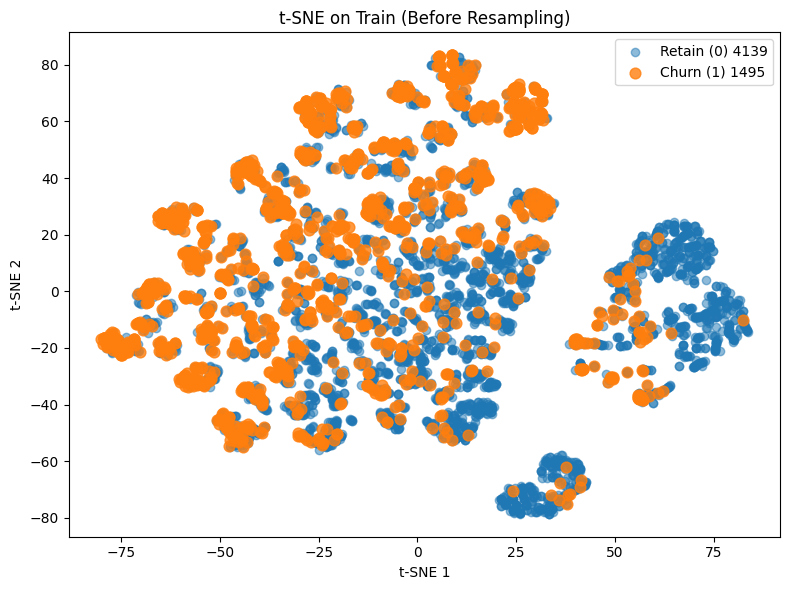

→ 두 클래스가 많이 겹치면 분류가 어렵고, Resampling 효과를 기대할 수 있음


In [16]:
# [Section 5-1] t-SNE — train 데이터 클래스 분리 확인
# (plot title/label: English)

tsne = TSNE(n_components=2, init="random", learning_rate="auto", perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_train)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[Y_train == 0, 0], X_tsne[Y_train == 0, 1], label=f"Retain (0) {(Y_train==0).sum()}", alpha=0.5)
plt.scatter(X_tsne[Y_train == 1, 0], X_tsne[Y_train == 1, 1], label=f"Churn (1) {(Y_train==1).sum()}", alpha=0.8, s=60)
plt.title("t-SNE on Train (Before Resampling)")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.legend()
plt.tight_layout()
plt.show()

print("→ 두 클래스가 많이 겹치면 분류가 어렵고, Resampling 효과를 기대할 수 있음")


**[과제]** 써니는 클래스 불균형을 완화하기 위해 여러 Resampling 기법(TomekLinks, SMOTE, SMOTE+TomekLinks, ADASYN)을 학습 데이터에 적용해보고 t-SNE로 데이터 분포가 어떻게 변하는지 궁금해졌습니다. AI와 함께 관련 코드를 작성하고 분석해보세요.

> Tip: Resampling은 학습 데이터에만 적용하고, 테스트 데이터는 원본 그대로 유지할 것

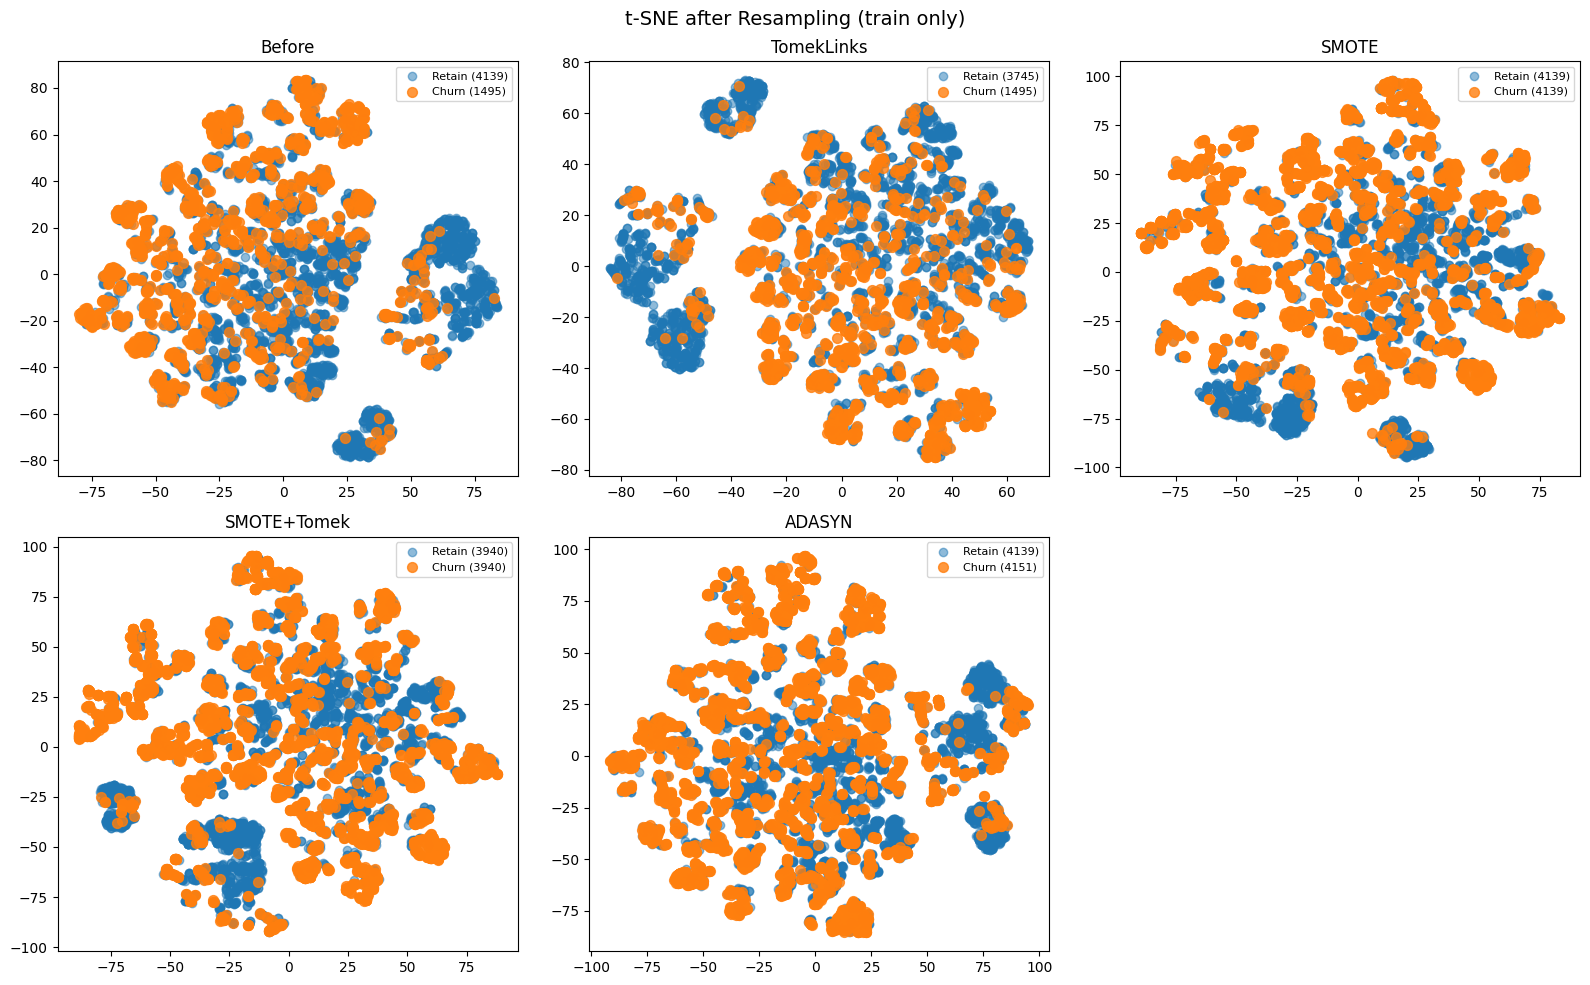

=== Resampling 후 클래스 수 ===
Before        Retain= 4139  Churn= 1495
TomekLinks    Retain= 3745  Churn= 1495
SMOTE         Retain= 4139  Churn= 4139
SMOTE+Tomek   Retain= 3940  Churn= 3940
ADASYN        Retain= 4139  Churn= 4151


In [15]:
# [Section 5-2] Resampling 적용 + t-SNE 비교 (train only)
# (plot title/label: English)

sampling_datasets = {
    "Before": (X_train.copy(), Y_train.copy()),
    "TomekLinks": TomekLinks().fit_resample(X_train, Y_train),
    "SMOTE": SMOTE(random_state=42).fit_resample(X_train, Y_train),
    "SMOTE+Tomek": SMOTETomek(random_state=42).fit_resample(X_train, Y_train),
    "ADASYN": ADASYN(random_state=42).fit_resample(X_train, Y_train),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, (X_s, Y_s)) in enumerate(sampling_datasets.items()):
    X_s = pd.DataFrame(X_s, columns=X_train.columns)
    emb = TSNE(n_components=2, init="random", learning_rate="auto", perplexity=30, random_state=42).fit_transform(X_s)
    axes[i].scatter(emb[Y_s == 0, 0], emb[Y_s == 0, 1], label=f"Retain ({(Y_s==0).sum()})", alpha=0.5)
    axes[i].scatter(emb[Y_s == 1, 0], emb[Y_s == 1, 1], label=f"Churn ({(Y_s==1).sum()})", alpha=0.8, s=50)
    axes[i].set_title(name)
    axes[i].legend(fontsize=8)

axes[-1].axis("off")
plt.suptitle("t-SNE after Resampling (train only)", fontsize=14)
plt.tight_layout()
plt.show()

print("=== Resampling 후 클래스 수 ===")
for name, (_, y_s) in sampling_datasets.items():
    print(f"{name:12s}  Retain={ (y_s==0).sum():5d}  Churn={ (y_s==1).sum():5d}")


**[과제]** 써니는 Resampling 기법별로 분류 모델(예: XGBoost)을 학습시켜 성능을 비교하려고 합니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

In [17]:
# [Section 5-3] Resampling별 XGBoost 성능 비교 (test, F1 기준)

results = []
for name, (X_tr, Y_tr) in sampling_datasets.items():
    neg, pos = (Y_tr == 0).sum(), (Y_tr == 1).sum()
    scale_pos_weight = neg / pos if pos > 0 else 1

    model = XGBClassifier(
        n_estimators=100, max_depth=6,
        scale_pos_weight=scale_pos_weight, random_state=42,
        eval_metric="logloss",
    )
    model.fit(X_tr, Y_tr)
    pred = model.predict(X_test)

    results.append({
        "Method": name,
        "Precision": round(precision_score(Y_test, pred, pos_label=1), 4),
        "Recall": round(recall_score(Y_test, pred, pos_label=1), 4),
        "F1-score": round(f1_score(Y_test, pred, pos_label=1), 4),
    })

result_df = pd.DataFrame(results).sort_values("F1-score", ascending=False)
print("=== Resampling XGBoost 성능 (test) ===")
print(result_df.to_string(index=False))
result_df


=== Resampling XGBoost 성능 (test) ===
     Method  Precision  Recall  F1-score
      SMOTE     0.5553  0.6845    0.6132
     ADASYN     0.5307  0.7166    0.6098
SMOTE+Tomek     0.5381  0.6791    0.6005
     Before     0.5346  0.6818    0.5993
 TomekLinks     0.5254  0.6925    0.5975


,Method,Precision,Recall,F1-score
2,SMOTE,0.5553,0.6845,0.6132
4,ADASYN,0.5307,0.7166,0.6098
3,SMOTE+Tomek,0.5381,0.6791,0.6005
0,Before,0.5346,0.6818,0.5993
1,TomekLinks,0.5254,0.6925,0.5975


## 6) SVDD (One-Class SVM) 적용

**[과제]** 써니는 Resampling 방식 대신, 정상(Non-Churn) 데이터만으로 정상 영역을 학습하는 One-Class Learning 접근은 성능이 어떨지 궁금해졌습니다. AI와 함께 One-Class SVM(SVDD)을 정상 데이터로만 학습시키고 Churn 샘플이 그 경계 밖으로 얼마나 잘 걸러지는지 코드를 작성하고 분석해보세요.

> Tip: 정상 데이터로만 학습하고 테스트는 정상/이상 모두 진행

In [18]:
# [Section 6-1] One-Class SVM — Non-Churn(정상)만 학습

X_train_normal = X_train[Y_train == 0]
print(f"학습 데이터 (Retain only): {X_train_normal.shape}")
print(f"테스트: Retain={(Y_test==0).sum()}, Churn={(Y_test==1).sum()}")

oc_svm = OneClassSVM(kernel="rbf", gamma="auto", nu=0.1)
oc_svm.fit(X_train_normal)

oc_pred = oc_svm.predict(X_test)          # 정상=1, 이상치=-1
y_pred_churn = (oc_pred == -1).astype(int)  # Churn=1로 변환

print("\n=== One-Class SVM (nu=0.1) 성능 ===")
print(f"Precision: {precision_score(Y_test, y_pred_churn, pos_label=1):.4f}")
print(f"Recall   : {recall_score(Y_test, y_pred_churn, pos_label=1):.4f}")
print(f"F1-score : {f1_score(Y_test, y_pred_churn, pos_label=1):.4f}")
print("\nConfusion Matrix (rows=true, cols=pred):")
print(confusion_matrix(Y_test, y_pred_churn))

print("\n[해석] predict: 1=정상(inlier), -1=이상치(outlier)")
print("       Churn(1) 고객이 -1로 잘 걸러지는지 Recall 확인")


학습 데이터 (Retain only): (4139, 19)
테스트: Retain=1035, Churn=374

=== One-Class SVM (nu=0.1) 성능 ===
Precision: 0.3469
Recall   : 0.1364
F1-score : 0.1958

Confusion Matrix (rows=true, cols=pred):
[[939  96]
 [323  51]]

[해석] predict: 1=정상(inlier), -1=이상치(outlier)
       Churn(1) 고객이 -1로 잘 걸러지는지 Recall 확인


**[과제]** 써니는 `nu` 값에 따라 SVDD의 경계와 성능이 어떻게 달라지는지 궁금해졌습니다. AI와 함께 관련 코드를 작성하고 분석해보세요.

=== nu별 One-Class SVM 성능 ===
  nu  Precision  Recall  F1-score
0.01     0.3889  0.0374    0.0683
0.05     0.3750  0.0802    0.1322
0.10     0.3469  0.1364    0.1958
0.15     0.3378  0.2005    0.2517
0.20     0.3243  0.2567    0.2866
0.30     0.3110  0.3717    0.3386
0.50     0.2999  0.5909    0.3978


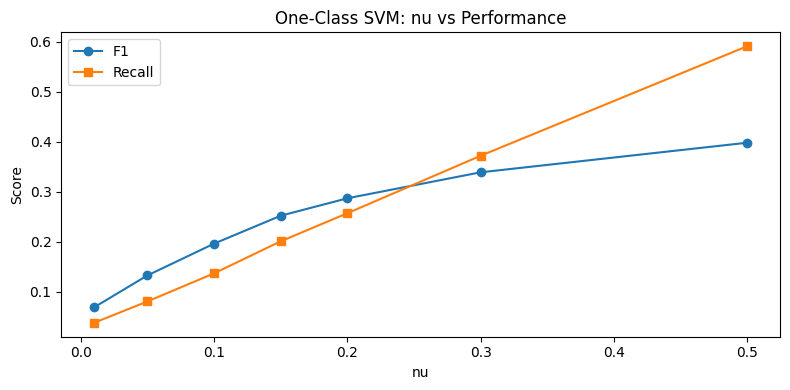


최고 F1 nu = 0.5


In [19]:
# [Section 6-2] nu 변화에 따른 SVDD 성능

nu_results = []
for nu in [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]:
    model = OneClassSVM(kernel="rbf", gamma="auto", nu=nu)
    model.fit(X_train_normal)
    pred = model.predict(X_test)
    y_pred = (pred == -1).astype(int)
    nu_results.append({
        "nu": nu,
        "Precision": round(precision_score(Y_test, y_pred, pos_label=1), 4),
        "Recall": round(recall_score(Y_test, y_pred, pos_label=1), 4),
        "F1-score": round(f1_score(Y_test, y_pred, pos_label=1), 4),
    })

nu_result_df = pd.DataFrame(nu_results)
print("=== nu별 One-Class SVM 성능 ===")
print(nu_result_df.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.plot(nu_result_df["nu"], nu_result_df["F1-score"], marker="o", label="F1")
plt.plot(nu_result_df["nu"], nu_result_df["Recall"], marker="s", label="Recall")
plt.xlabel("nu"); plt.ylabel("Score")
plt.title("One-Class SVM: nu vs Performance")
plt.legend()
plt.tight_layout()
plt.show()

best_nu = nu_result_df.loc[nu_result_df["F1-score"].idxmax(), "nu"]
print(f"\n최고 F1 nu = {best_nu}")


## 7) 모델 결과 분석 및 비교

**[과제]** 써니는 지금까지 클래스 불균형 해결을 위해 시도한 Resampling과 One-Class Learning 중, 이 이탈 탐지 문제에는 어떤 접근이 더 적합한지 판단하고자 합니다. AI와 함께 두 접근의 성능을 한 표에 정리하고 어떤 상황에서 어떤 방법이 유리한지 인사이트를 도출해 보세요.

In [20]:
# [Section 7] Resampling vs One-Class Learning — 최종 비교

# --- 1) Resampling + XGBoost (5개 전부) ---
compare_rows = []
for _, row in result_df.iterrows():
    compare_rows.append({
        "Method": row["Method"],
        "Approach": "Resampling + XGBoost",
        "Precision": row["Precision"],
        "Recall": row["Recall"],
        "F1-score": row["F1-score"],
    })

# --- 2) One-Class SVM (nu 스윕 최고 + 기본 nu=0.1) ---
oc_nu_list = [("best nu", float(best_nu))]
if float(best_nu) != 0.1:
    oc_nu_list.append(("nu=0.1", 0.1))
for label, nu_val in oc_nu_list:
    row = nu_result_df[nu_result_df["nu"] == nu_val].iloc[0]
    compare_rows.append({
        "Method": f"One-Class SVM ({label})",
        "Approach": "One-Class SVM",
        "Precision": row["Precision"],
        "Recall": row["Recall"],
        "F1-score": row["F1-score"],
    })

final_compare = pd.DataFrame(compare_rows).sort_values("F1-score", ascending=False).reset_index(drop=True)

print("=== 최종 성능 비교표 (test, F1 기준 정렬) ===")
print(final_compare.to_string(index=False))

best_resample = final_compare[final_compare["Approach"] == "Resampling + XGBoost"].iloc[0]
best_oc = final_compare[final_compare["Approach"] == "One-Class SVM"].iloc[0]

print(f"""
=== 인사이트 ===

[이 Churn 데이터 (~26.5% 이탈)]
  - Resampling 최고: {best_resample['Method']} (F1={best_resample['F1-score']})
  - One-Class 최고:  {best_oc['Method']} (F1={best_oc['F1-score']})
  - Churn 라벨 1,800+개 → 지도학습 + Resampling이 일반적으로 유리
  - 라벨된 이탈 정보를 활용하는 XGBoost가 One-Class보다 성능 우위인 경우가 많음

[Resampling + XGBoost가 유리한 경우]
  - 소수 클래스 라벨이 수백 개 이상 (지도학습 가능)
  - 변수가 많고 비선형 패턴 (트리 모델)

[One-Class SVM이 유리한 경우]
  - 불량/이탈 라벨이 극히 적을 때 (대략 1~5% 미만, 수십 건 미만)
  - 정상만 충분하고 '미지의 이상' 탐지가 목표일 때

[최종 추천]
  → 이 프로젝트: Resampling + XGBoost ({best_resample['Method']})
  → F1 기준으로 최종 모델 선정
""")

final_compare


=== 최종 성능 비교표 (test, F1 기준 정렬) ===
                 Method             Approach  Precision  Recall  F1-score
                  SMOTE Resampling + XGBoost     0.5553  0.6845    0.6132
                 ADASYN Resampling + XGBoost     0.5307  0.7166    0.6098
            SMOTE+Tomek Resampling + XGBoost     0.5381  0.6791    0.6005
                 Before Resampling + XGBoost     0.5346  0.6818    0.5993
             TomekLinks Resampling + XGBoost     0.5254  0.6925    0.5975
One-Class SVM (best nu)        One-Class SVM     0.2999  0.5909    0.3978
 One-Class SVM (nu=0.1)        One-Class SVM     0.3469  0.1364    0.1958

=== 인사이트 ===

[이 Churn 데이터 (~26.5% 이탈)]
  - Resampling 최고: SMOTE (F1=0.6132)
  - One-Class 최고:  One-Class SVM (best nu) (F1=0.3978)
  - Churn 라벨 1,800+개 → 지도학습 + Resampling이 일반적으로 유리
  - 라벨된 이탈 정보를 활용하는 XGBoost가 One-Class보다 성능 우위인 경우가 많음

[Resampling + XGBoost가 유리한 경우]
  - 소수 클래스 라벨이 수백 개 이상 (지도학습 가능)
  - 변수가 많고 비선형 패턴 (트리 모델)

[One-Class SVM이 유리한 경우]
  - 불량/이탈 라벨이 극히 적

,Method,Approach,Precision,Recall,F1-score
0,SMOTE,Resampling + XGBoost,0.5553,0.6845,0.6132
1,ADASYN,Resampling + XGBoost,0.5307,0.7166,0.6098
2,SMOTE+Tomek,Resampling + XGBoost,0.5381,0.6791,0.6005
3,Before,Resampling + XGBoost,0.5346,0.6818,0.5993
4,TomekLinks,Resampling + XGBoost,0.5254,0.6925,0.5975
5,One-Class SVM (best nu),One-Class SVM,0.2999,0.5909,0.3978
6,One-Class SVM (nu=0.1),One-Class SVM,0.3469,0.1364,0.1958
